In [10]:
import torch
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
sys.path.append('../')
from utilities import load_embedding, print_exams
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from IPython.display import clear_output
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from joblib import Parallel, delayed
from tqdm import tqdm


In [43]:
class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)

    return pd.DataFrame(merged_rows)

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def monte_carlo_preds(model, dataloader, emb_dict, device, T=20):
    all_preds = []
    all_labels = []
    seed_base = 42
    model.train()
    Total_iter = T*len(dataloader)
    progress_bar = tqdm(range(Total_iter), desc="Monte Carlo Predictions")
    for t in range(T):
        for batch in dataloader:
            with torch.no_grad():
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[0]])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[1]])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[2]])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] for key in batch[3]])
                strainPassCats, labels = batch[4], batch[5]
                matrixs_a, matrixs_b, matrixs_c, matrixs_d= matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
                strainPassCats, labels = strainPassCats.to(device), labels.to(device)

                torch.manual_seed(seed_base + t)
                torch.cuda.manual_seed_all(seed_base + t)
                
                _, _, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
                all_preds.append([item[0].item() for item in output])
                all_labels.append(labels)
                progress_bar.update(1)
    
    progress_bar.close()
    return all_preds, all_labels

def group_and_filt(DF, fill_word=None):
    group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
    agg_dict = {c: 'first' for c in DF.columns if c not in group_columns}
    agg_dict['label'] = 'mean'
    Active_final = DF.groupby(group_columns).agg(agg_dict).reset_index()

    if fill_word is not None:
        Active_final['seq_id_a'] = Active_final['seq_id_a'] + fill_word
        Active_final['seq_id_b'] = Active_final['seq_id_b'] + fill_word
        Active_final['seq_id_c'] = Active_final['seq_id_c'] + fill_word
        Active_final['seq_id_d'] = Active_final['seq_id_d'] + fill_word
    
    return Active_final

def retrive_feature_vector(model, dataloader, emb_dict, device, emb_in_device=False, save_path=None):
    model.eval()
    Total_iter = len(dataloader)
    progress_bar = tqdm(range(Total_iter), desc="Retrive Feature Vector")
    for batch in dataloader:
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
        matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_d])

        if emb_in_device == False:
            matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)

        masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
        strainPassCats, labels = strainPassCats.to(device), labels.to(device)
        
        with torch.no_grad():
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                        save_concat_vector=save_path)

        progress_bar.update(1)
    progress_bar.close()

def elbow_method(data, K_min=5, K_max=300, step=5, n_jobs=-1, random_state=42, figsize=(12, 6)):
    """
    使用肘部法则 (Elbow Method) 绘制不同 K 值下的 SSE 曲线

    参数
    ----------
    data : ndarray
        输入的数据矩阵 (样本数 × 特征数)
    K_min : int, default=5
        K 的最小值
    K_max : int, default=300
        K 的最大值
    step : int, default=5
        K 的步长
    n_jobs : int, default=-1
        并行计算时的 CPU 核心数，-1 表示使用所有核心
    random_state : int, default=42
        随机种子
    figsize : tuple, default=(12, 6)
        绘图大小
    """

    K_range = range(K_min, K_max + 1, step)

    def compute_sse(K):
        kmeans = KMeans(n_clusters=K, random_state=random_state)
        kmeans.fit(data)
        return kmeans.inertia_

    sse = Parallel(n_jobs=n_jobs)(delayed(compute_sse)(K) for K in K_range)

    # 绘制图像
    plt.figure(figsize=figsize)
    plt.plot(K_range, sse, marker='o')
    plt.title(f'Elbow Method (K={K_min}-{K_max}, step={step})')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('SSE (Sum of Squared Errors)')
    plt.grid(True)
    plt.show()


In [35]:
device = torch.device('cuda:0')
Crick_train = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/titer/train.csv', index_col=False)
Crick_test = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/titer/test.csv', index_col=False)
Active_data_41 = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/Crick_41.csv', index_col=False)
Active_data_42 = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/Crick_42.csv', index_col=False)
Active_data_43 = pd.read_csv('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/Crick_43.csv', index_col=False)
Active_data_43['serumPassCat'] = '<' + Active_data_43['serumPassCat'] + '>'
Active_data_43['virusPassCat'] = '<' + Active_data_43['virusPassCat'] + '>'

Active_data_41 = group_and_filt(Active_data_41, fill_word='_41')
Active_data_42 = group_and_filt(Active_data_42, fill_word='_42')
Active_data_43 = group_and_filt(Active_data_43, fill_word='_43')

Active_final = pd.concat([Active_data_41, Active_data_42, Active_data_43])
Active_final = group_and_filt(Active_final, fill_word=None)

Active_candidate, Active_test = train_test_split(Active_final, test_size=0.1, random_state=42)
Active_candidate, Active_valid = train_test_split(Active_candidate, test_size=1/9, random_state=42)

In [37]:
batch_size = 8
Active_candidate_dataloader = DataLoader(fluProfiler_Dataset(Active_candidate), batch_size=batch_size, shuffle=True)
Active_valid_dataloader = DataLoader(fluProfiler_Dataset(Active_valid), batch_size=batch_size, shuffle=False)
Active_test_dataloader = DataLoader(fluProfiler_Dataset(Active_test), batch_size=batch_size, shuffle=False)

In [ ]:
# load embedding
emb_dict_41 = load_embedding("/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_41")
emb_dict_42 = load_embedding("/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_42")
emb_dict_43 = load_embedding("/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/embedding_43")

Loading tensor: 100%|██████████| 750/750 [01:33<00:00,  7.98file/s]


In [13]:
emb_dict_41 = {key + '_41': value for key, value in emb_dict_41.items()}
emb_dict_42 = {key + '_42': value for key, value in emb_dict_42.items()}
emb_dict_43 = {key + '_43': value for key, value in emb_dict_43.items()}

emb_dict_414243 = emb_dict_41 | emb_dict_42 | emb_dict_43

In [39]:
emb_dict_414243 = {key:value.to(device) for key, value in emb_dict_414243.items()}

## 使用聚类筛选代表性样本

In [88]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Active_candidate_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    matrixs_a, masks_a = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_active[key.replace('_active', '')] for key in emb_file_name_d])
    
    matrixs_a = matrixs_a.to(device)
    matrixs_b = matrixs_b.to(device)
    matrixs_c = matrixs_c.to(device)
    matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_41')
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())
result = print_exams(test_prediction_ls, test_reference_ls)

MAE: 0.68567
MSE: 0.75857
pearson correlation: 0.68711
spearman correlation: 0.70560
R2_score: 0.45278


In [40]:
model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
retrive_feature_vector(model, Active_candidate_dataloader, emb_dict_414243, device, emb_in_device=True, save_path='/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_414243')

Retrive Feature Vector:   0%|          | 0/1099 [01:12<?, ?it/s]


In [41]:
dict_path = '/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/data/data_40/vector_414243'
files = os.listdir(dict_path)
files = sorted(files, key=lambda x: int(x.replace('.pth', '')))
my_tensors = []
for file in files:
    my_tensors.append(torch.load(os.path.join(dict_path, file), weights_only=False))
active_candidate_tensor = torch.cat(my_tensors, dim=0).cpu().numpy()

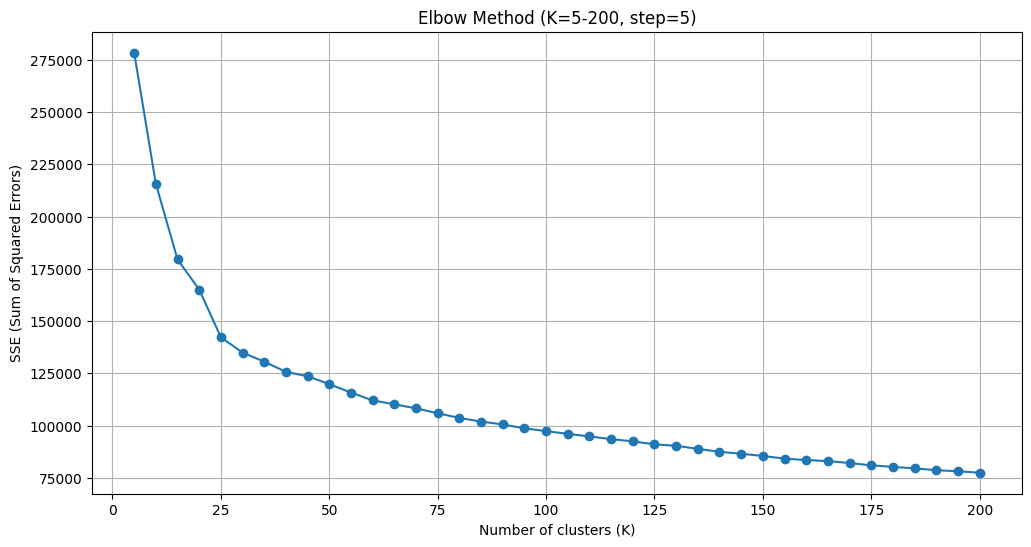

In [45]:
## 肘部法参考聚类类数
elbow_method(active_candidate_tensor, K_min=5, K_max=200, step=5)

In [52]:
sample_size = 200

kmeans = KMeans(n_clusters=200, random_state=42, n_init=10)
kmeans.fit(active_candidate_tensor)

Active_candidate['cluster'] = pd.Series(kmeans.labels_).tolist()

selected_cluster = pd.Series(kmeans.labels_).value_counts()
selected_cluster = selected_cluster[selected_cluster >= 5]

sample_ratio = sample_size / selected_cluster.sum()
selected_sample = Active_candidate[Active_candidate['cluster'].isin(selected_cluster.index)]

active_selection = Active_candidate.groupby('cluster', group_keys=False).apply(lambda x: x.sample(frac=sample_ratio), include_groups=False)
random_selection = Active_candidate.sample(active_selection.shape[0], random_state=42)

active_dataloader = DataLoader(fluProfiler_Dataset(active_selection), batch_size=8, shuffle=False)
random_dataloader = DataLoader(fluProfiler_Dataset(random_selection), batch_size=8, shuffle=False)

In [54]:
sample_size = 50
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
kmeans.fit(active_candidate_tensor)

Active_candidate['cluster'] = kmeans.labels_

# 2. 过滤掉样本数 < 5 的簇
selected_cluster = pd.Series(kmeans.labels_).value_counts()
selected_cluster = selected_cluster[selected_cluster >= 5]

# 3. 在每个簇里选取离中心最近的样本
closest_indices = []
for cluster_id in selected_cluster.index:
    cluster_mask = (kmeans.labels_ == cluster_id)
    cluster_indices = np.where(cluster_mask)[0]

    # 计算这些点到簇中心的距离
    cluster_points = active_candidate_tensor[cluster_mask]
    distances = np.linalg.norm(cluster_points - kmeans.cluster_centers_[cluster_id], axis=1)

    # 取最近的那个点
    closest_idx = cluster_indices[np.argmin(distances)]
    closest_indices.append(closest_idx)

# 4. 得到最终的 active_selection
active_selection = Active_candidate.iloc[closest_indices]

# 5. 为对比，仍然从整体里随机采样相同数量
random_selection = Active_candidate.sample(active_selection.shape[0], random_state=42)

# 6. 转换成 DataLoader
active_dataloader = DataLoader(fluProfiler_Dataset(active_selection), batch_size=8, shuffle=False)
random_dataloader = DataLoader(fluProfiler_Dataset(random_selection), batch_size=8, shuffle=False)


In [49]:
def multidata_trainer(model, train_dataloader, valid_dataloader, test_dataloader, emb_dict, lr_rate, epoch=15):
    model.to(device)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                        lr=lr_rate,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)


    valid_MAE_ls = []
    valid_MSE_ls = []
    valid_Pearson_ls = []
    valid_Spearman_ls = []
    test_MAE_ls = []
    test_MSE_ls = []
    test_Pearson_ls = []
    test_Spearman_ls = []
    Pearson_ls = []
    Spearman_ls = []
    for epoch in range(epoch):
        model.train()
        loss_ls = []
        for batch in train_dataloader:
            emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
            
            matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
            matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
            matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
            matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

            # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        valid_prediction_ls = []
        valid_reference_ls = []
        valid_logits_ls = []
        model.eval()
        for batch in valid_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            valid_prediction_ls = valid_prediction_ls + output.view(-1).tolist()
            valid_reference_ls = valid_reference_ls + labels.tolist()
            valid_logits_ls.append(logits.tolist())
        
        valid_mae, valid_mse, valid_pearson, valid_spearman, R2 = print_exams(valid_reference_ls, valid_prediction_ls, print_result=False)
        valid_MAE_ls.append(valid_mae)
        valid_MSE_ls.append(valid_mse)
        valid_Pearson_ls.append(valid_pearson)
        valid_Spearman_ls.append(valid_spearman)

        test_prediction_ls = []
        test_reference_ls = []
        test_logits_ls = []
        model.eval()
        for batch in test_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
            test_reference_ls = test_reference_ls + labels.tolist()
            test_logits_ls.append(logits.tolist())
        
        test_mae, test_mse, test_pearson, test_spearman, R2 = print_exams(test_reference_ls, test_prediction_ls, print_result=False)
        test_MAE_ls.append(test_mae)
        test_MSE_ls.append(test_mse)
        test_Pearson_ls.append(test_pearson)
        test_Spearman_ls.append(test_spearman)


        epochs = list(range(1, len(valid_MSE_ls)+1))

        # 绘制折线图
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, valid_MSE_ls, label='valid MSE', marker='o')
        plt.plot(epochs, test_MSE_ls, label='test MSE', marker='x')

        plt.text(epochs[-1], valid_MSE_ls[-1], f'{valid_MSE_ls[-1]:.5f}', ha='center', va='bottom')
        plt.text(epochs[-1], test_MSE_ls[-1], f'{test_MSE_ls[-1]:.5f}', ha='center', va='top')

        # 添加标题和标签
        plt.title('MSE Changes Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        clear_output(wait=True)
        plt.show()
            
    return [test_MAE_ls, test_MSE_ls, test_Pearson_ls, test_Spearman_ls, R2]

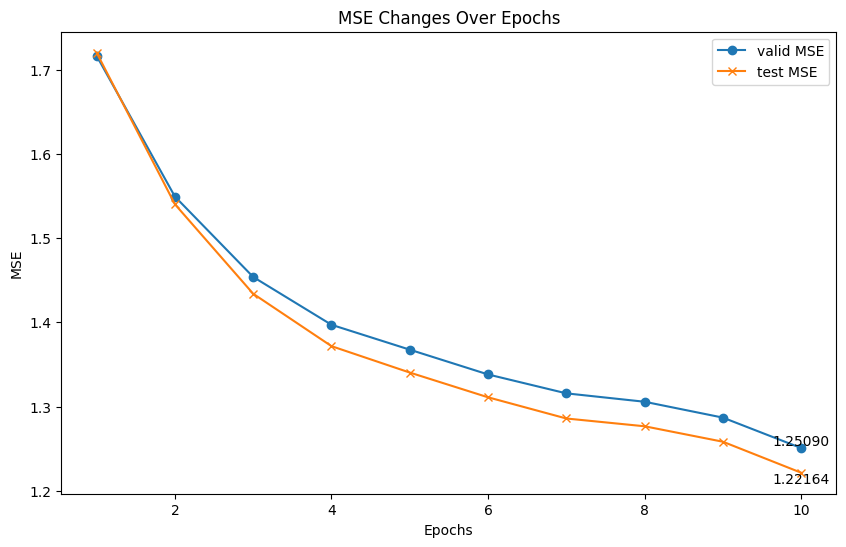

In [53]:
model_active = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
active_result = multidata_trainer(model_active, active_dataloader, Active_valid_dataloader, Active_test_dataloader, emb_dict_414243, lr_rate=0.00002, epoch=10)

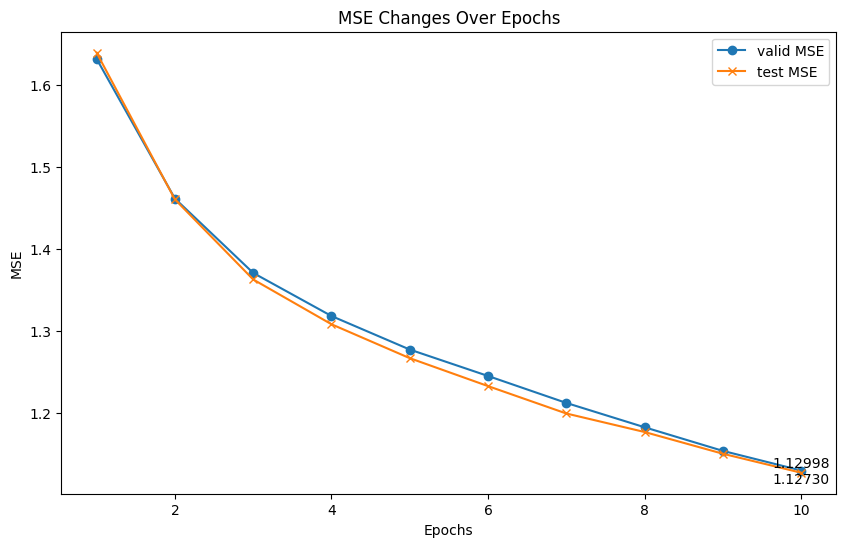

In [51]:
model_random = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
random_result = multidata_trainer(model_random, random_dataloader, Active_valid_dataloader, Active_test_dataloader, emb_dict_414243, lr_rate=0.00002, epoch=10)

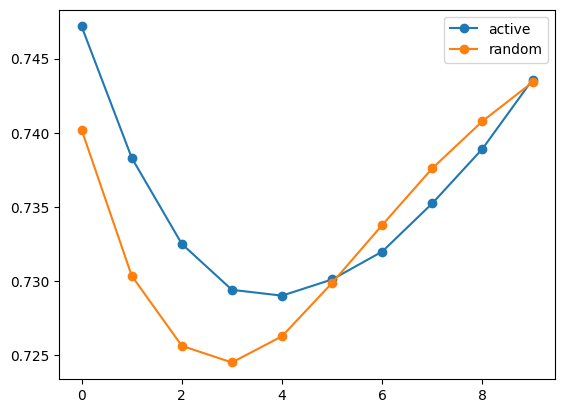

In [61]:
plt.plot(active_result[1], label='active', marker='o')
plt.plot(random_result[1], label='random', marker='o')
plt.legend()
plt.show()

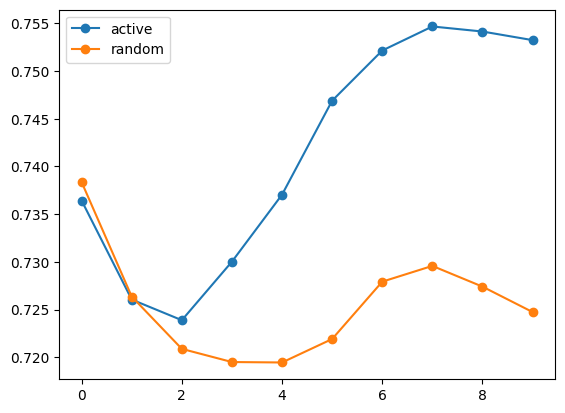

In [65]:
plt.plot(active_result[1], label='active', marker='o')
plt.plot(random_result[1], label='random', marker='o')
plt.legend()
plt.show()

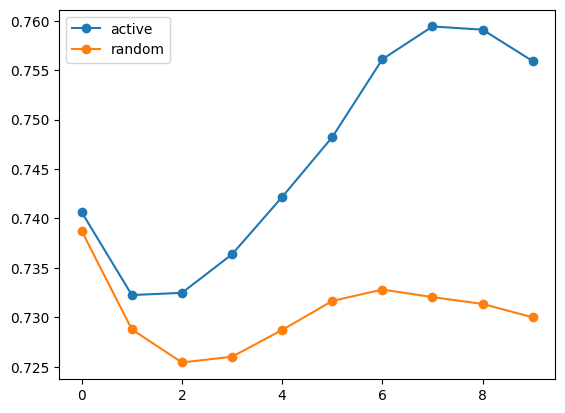

In [69]:
plt.plot(active_result[1], label='active', marker='o')
plt.plot(random_result[1], label='random', marker='o')
plt.legend()
plt.show()

## 使用大模型的表征进行聚类

In [39]:
Active_candidate.drop_duplicates(subset=['seq_id_a', 'seq_id_b', 'serumPassCat']).shape

(14, 18)

In [40]:
Active_candidate.shape

(1668, 18)